# Projeto Final — Introdução à Ciência de Dados
## Infrações de Trânsito nas Rodovias do Distrito Federal (2025)

**Integrantes**

- Gabriel Queiroz — gabriel.sabatino@sempreceub.com
- Cauan Bastos — cauan.br@sempreceub.com
- Joao Tarik — joao.tarik@sempreceub.com

**Fonte dos dados:** Portal de Dados Abertos do DF — *Infrações de Trânsito*
🔗 https://www.dados.df.gov.br/dataset/infracoes-transito

**Período analisado:** ano de 2025 (registro completo).

---

### Pergunta central do trabalho

> **Quais são os perfis de risco nas rodovias do Distrito Federal: onde, quando e como as infrações de trânsito se concentram, e o que esses padrões revelam sobre os fatores que mais contribuem para o comportamento infrator?**

A partir dessa pergunta principal, derivamos perguntas menores, cada uma respondida por um ou mais gráficos:

1. **ONDE** — Em quais rodovias do DF as infrações se concentram?
2. **QUANDO** — Existe diferença entre os meses do ano e os dias da semana no volume de infrações?
3. **QUANDO (hora)** — Em quais horários do dia as infrações acontecem mais?
4. **COMO** — Quais tipos de infração são mais cometidos e qual a gravidade predominante?
5. **QUEM** — Que tipos de veículo e de infrator mais aparecem nos registros?
6. **QUANTO** — Como se distribui o valor das multas e ele varia com a gravidade?

## 0. Preparação do ambiente

Importamos as bibliotecas e definimos um padrão visual único para todos os gráficos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re

# Padrão visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["font.size"] = 10

# Paleta de cores reaproveitada nos gráficos
COR = "#2E5E8C"
PALETA = "viridis"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print("Ambiente pronto.")

Ambiente pronto.


## 1. Entendimento e descrição do conjunto de dados

Carregamos o conjunto com pandas e exibimos as primeiras linhas.

In [2]:
# O arquivo está na mesma pasta do notebook
df = pd.read_parquet("dados_2025.parquet")
df.head()

,tipo_infracao,descricao,tipo_infrator,tipo_veiculo,cometimento,hora_cometimento,auinf_local_rodovia,auinf_local_km,auinf_local_referencia,auinf_local_complemento,auinf_local_latitude,auinf_local_longitude,grav_tipo,dia_da_semana,valor_multa
0,7463-0,transitar em velocidade superior a maxima perm...,condutor,automovel,2025-01-01,0 days 00:00:00,"rodovia df-001 (epct), km 64,0",Nao informado,Nao informado,Nao informado,Nao informado,Nao informado,grave,quarta-feira,195.23
1,7455-0,transitar em velocidade superior a maxima perm...,condutor,automovel,2025-01-01,0 days 00:00:00,"df-459 km 0,6 sentido ceilandia/samambaia",Nao informado,Nao informado,Nao informado,Nao informado,Nao informado,media,quarta-feira,130.16
2,7455-0,transitar em velocidade superior a maxima perm...,condutor,automovel,2025-01-01,0 days 00:01:00,"df-075 (epnb) km 5,7 sentido df-003 (epia)",Nao informado,Nao informado,Nao informado,Nao informado,Nao informado,media,quarta-feira,130.16
3,7455-0,transitar em velocidade superior a maxima perm...,condutor,automovel,2025-01-01,0 days 00:03:00,"df-011(epig) km 0,8 sent. eptg/eixo monumental...",Nao informado,Nao informado,Nao informado,Nao informado,Nao informado,media,quarta-feira,130.16
4,7455-0,transitar em velocidade superior a maxima perm...,condutor,automovel,2025-01-01,0 days 00:05:00,"rodovia df-003 (epia) km 22,6",Nao informado,Nao informado,Nao informado,Nao informado,Nao informado,media,quarta-feira,130.16


### 1.1. Tamanho do conjunto e tipos de coluna

In [3]:
print(f"O conjunto tem {df.shape[0]:,} linhas e {df.shape[1]} colunas.".replace(",", "."))
print()
df.info()

O conjunto tem 815.923 linhas e 15 colunas.

<class 'pandas.DataFrame'>
RangeIndex: 815923 entries, 0 to 815922
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype          
---  ------                   --------------   -----          
 0   tipo_infracao            815923 non-null  str            
 1   descricao                815923 non-null  str            
 2   tipo_infrator            815923 non-null  str            
 3   tipo_veiculo             815923 non-null  str            
 4   cometimento              815923 non-null  datetime64[ns] 
 5   hora_cometimento         815923 non-null  timedelta64[ns]
 6   auinf_local_rodovia      815923 non-null  str            
 7   auinf_local_km           815923 non-null  str            
 8   auinf_local_referencia   815923 non-null  str            
 9   auinf_local_complemento  815923 non-null  str            
 10  auinf_local_latitude     815923 non-null  str            
 11  auinf_local_longitude    815923

### 1.2. O que cada coluna significa

Com base na documentação do Portal de Dados Abertos do DF, cada coluna representa:

| Coluna | Significado | Tipo |
|---|---|---|
| `tipo_infracao` | Código da infração no CTB (ex.: `7455-0`) | Categórica (texto) |
| `descricao` | Descrição textual da infração cometida | Categórica (texto) |
| `tipo_infrator` | Quem responde pela infração (condutor, proprietário, etc.) | Categórica |
| `tipo_veiculo` | Tipo do veículo envolvido (automóvel, motocicleta, etc.) | Categórica |
| `cometimento` | Data em que a infração foi cometida | Data |
| `hora_cometimento` | Horário do cometimento | Hora (tempo) |
| `auinf_local_rodovia` | Texto do local/rodovia onde ocorreu | Texto |
| `auinf_local_km` | Quilômetro do local | Texto |
| `auinf_local_referencia` | Referência do local | Texto |
| `auinf_local_complemento` | Complemento do endereço | Texto |
| `auinf_local_latitude` | Latitude do local | Texto (deveria ser numérica) |
| `auinf_local_longitude` | Longitude do local | Texto (deveria ser numérica) |
| `grav_tipo` | Gravidade da infração (leve, média, grave, gravíssima) | Categórica (ordinal) |
| `dia_da_semana` | Dia da semana do cometimento | Categórica |
| `valor_multa` | Valor da multa em reais (R$) | Numérica |

A coluna numérica de interesse é `valor_multa`. As colunas `cometimento` e `hora_cometimento` são temporais e as demais são categóricas/texto.

### 1.3. Estatísticas básicas da coluna numérica

A única coluna genuinamente numérica é `valor_multa`. Latitude e longitude vieram como **texto** e, como veremos na limpeza, estão corrompidas demais para uso, então não entram aqui.

In [4]:
stats = df["valor_multa"].agg(["count", "mean", "median", "min", "max", "std"])
moda = df["valor_multa"].mode().iloc[0]

print("Estatísticas de valor_multa (R$):")
print(f"  Contagem (não nulos): {int(stats['count']):,}".replace(",", "."))
print(f"  Média   : R$ {stats['mean']:.2f}")
print(f"  Mediana : R$ {stats['median']:.2f}")
print(f"  Moda    : R$ {moda:.2f}")
print(f"  Mínimo  : R$ {stats['min']:.2f}")
print(f"  Máximo  : R$ {stats['max']:.2f}")
print(f"  Desvio padrão: R$ {stats['std']:.2f}")

Estatísticas de valor_multa (R$):
  Contagem (não nulos): 811.231
  Média   : R$ 164.31
  Mediana : R$ 130.16
  Moda    : R$ 130.16
  Mínimo  : R$ 88.38
  Máximo  : R$ 2934.70
  Desvio padrão: R$ 142.12


> **Leitura inicial:** a média (R\$ 164) é bem maior que a mediana e a moda (R\$ 130,16), indicando uma distribuição **assimétrica à direita**: a maioria das multas é de valor baixo/médio, mas existe uma cauda de multas caras (até R\$ 2.934) que puxa a média para cima.

## 2. Avaliação de completude e limpeza dos dados

### 2.1. Valores faltantes (nulos)

In [5]:
nulos = df.isna().sum()
prop = (nulos / len(df) * 100).round(2)
tab_nulos = pd.DataFrame({"qtd_nulos": nulos, "proporcao_%": prop})
tab_nulos[tab_nulos["qtd_nulos"] > 0]

,qtd_nulos,proporcao_%
valor_multa,4692,0.58


Apenas `valor_multa` tem nulos de fato (`NaN`): **4.692 linhas (~0,58%)**.

Porém, várias colunas de texto usam o rótulo **`"Nao informado"`** no lugar de um nulo de verdade. Precisamos contá-los explicitamente, porque para fins de análise eles são tão "vazios" quanto um nulo.

In [6]:
texto_cols = df.select_dtypes(include="object").columns
ni = {c: (df[c].str.lower() == "nao informado").sum() for c in texto_cols}
ni = pd.Series(ni).sort_values(ascending=False)
ni = ni[ni > 0]
tab_ni = pd.DataFrame({"qtd_nao_informado": ni,
                       "proporcao_%": (ni / len(df) * 100).round(2)})
tab_ni

/tmp/ipykernel_638/15854912.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  texto_cols = df.select_dtypes(include="object").columns


,qtd_nao_informado,proporcao_%
auinf_local_complemento,791538,97.01
auinf_local_latitude,606199,74.30
auinf_local_longitude,606199,74.30
auinf_local_referencia,562967,69.00
auinf_local_km,559312,68.55
auinf_local_rodovia,1987,0.24


**Conclusão sobre completude:**

- As colunas de **geolocalização** (`latitude`, `longitude`), `km`, `referencia` e `complemento` estão majoritariamente preenchidas com `"Nao informado"` (70%–97%). **Não são confiáveis para análise.**
- As colunas que vamos efetivamente usar — `descricao`, `grav_tipo`, `tipo_veiculo`, `tipo_infrator`, `cometimento`, `dia_da_semana` — estão **completas** (0 nulos, 0 "Nao informado").

### 2.2. Duplicatas

In [7]:
n_dup = df.duplicated().sum()
print(f"Linhas totalmente duplicadas: {n_dup:,}".replace(",", "."))
print(f"Proporção: {n_dup/len(df)*100:.2f}%")

Linhas totalmente duplicadas: 27.046
Proporção: 3.31%


> **Decisão:** Encontramos 27.046 linhas idênticas em **todas** as colunas. Como o conjunto não tem um identificador único (ID do auto de infração), duas multas diferentes poderiam, em tese, coincidir em todos os campos (mesma infração, mesmo veículo, mesma rodovia, mesmo dia e mesmo minuto). Esse risco é pequeno e tratamos linhas 100% idênticas como **registros repetidos**, removendo-os para não inflar artificialmente as contagens. Documentamos a decisão por transparência.

### 2.3. Tipagem e valores fora do padrão

Verificamos três problemas:

1. **Latitude/longitude lidas como texto** e, quando convertidas, com valores impossíveis.
2. **Categorias de veículo truncadas/duplicadas** (ex.: `caminhonet` vs `caminhonete`, `motociclet` vs `motocicleta`).
3. **`hora_cometimento`** veio como `timedelta`, que precisamos transformar em "hora do dia" para analisar.

In [8]:
# 1) Testando a conversão de latitude/longitude
lat = pd.to_numeric(df["auinf_local_latitude"].str.replace(",", ".", regex=False), errors="coerce")
lon = pd.to_numeric(df["auinf_local_longitude"].str.replace(",", ".", regex=False), errors="coerce")
print("Latitude  -> válidos:", f"{lat.notna().sum():,}".replace(",", "."),
      "| faixa:", round(lat.min(), 1), "a", round(lat.max(), 1))
print("Longitude -> válidos:", f"{lon.notna().sum():,}".replace(",", "."),
      "| faixa:", round(lon.min(), 1), "a", round(lon.max(), 1))
print()
print("O DF fica em torno de lat -15,8 / lon -47,9. Os valores acima incluem")
print("coordenadas impossíveis (lat -161, lon -482) e só ~3% são preenchidos.")
print("=> DESCARTAMOS lat/long da análise espacial.")

Latitude  -> válidos: 25.371 | faixa: -161.8 a 0.0
Longitude -> válidos: 25.319 | faixa: -482.4 a 0.0

O DF fica em torno de lat -15,8 / lon -47,9. Os valores acima incluem
coordenadas impossíveis (lat -161, lon -482) e só ~3% são preenchidos.
=> DESCARTAMOS lat/long da análise espacial.


**Por isso, a dimensão "ONDE" será respondida pela coluna `auinf_local_rodovia`** (texto da rodovia), extraindo o código da via DF/BR com expressão regular. É a informação de local confiável que sobra.

In [9]:
# ---------- LIMPEZA APLICADA ----------
df_limpo = df.copy()

# (a) Remover duplicatas exatas
antes = len(df_limpo)
df_limpo = df_limpo.drop_duplicates().reset_index(drop=True)
print(f"Duplicatas removidas: {antes - len(df_limpo):,}".replace(",", "."))

# (b) valor_multa nulo: removemos as linhas (0,58%) por serem poucas e
#     não termos como inferir o valor correto.
antes = len(df_limpo)
df_limpo = df_limpo.dropna(subset=["valor_multa"]).reset_index(drop=True)
print(f"Linhas sem valor_multa removidas: {antes - len(df_limpo):,}".replace(",", "."))

# (c) Normalizar tipo_veiculo: corrigir truncamentos
mapa_veiculo = {
    "caminhonet": "caminhonete",
    "motociclet": "motocicleta",
    "microonibu": "microonibus",
    "s.reboque": "semi-reboque",
    "c. trator": "caminhao trator",
    "motor-casa": "motor casa",
    "tr rodas": "trator de rodas",
}
df_limpo["tipo_veiculo"] = df_limpo["tipo_veiculo"].replace(mapa_veiculo)

# (d) hora_cometimento (timedelta) -> hora inteira do dia (0 a 23)
df_limpo["hora"] = (df_limpo["hora_cometimento"].dt.total_seconds() // 3600).astype(int)

# (e) Mês a partir da data
df_limpo["mes"] = df_limpo["cometimento"].dt.month

# (f) Extrair o código da rodovia (df-001, df-075, br-020 ...) do texto
def extrai_rodovia(texto):
    t = str(texto).lower()
    m = re.search(r"\b(df|br)\s*-?\s*(\d{3})\b", t)
    if m:
        return f"{m.group(1)}-{m.group(2)}"
    m2 = re.match(r"^\s*(\d{3})\b", t)  # casos onde sobrou só "001", "075"
    if m2:
        return f"df-{m2.group(1)}"
    return "outra/nao identificada"

df_limpo["rodovia"] = df_limpo["auinf_local_rodovia"].apply(extrai_rodovia)

# (g) Gravidade como categoria ordenada
ordem_grav = ["leve", "media", "grave", "gravissima"]
df_limpo["grav_tipo"] = pd.Categorical(df_limpo["grav_tipo"], categories=ordem_grav, ordered=True)

print(f"\nConjunto após limpeza: {len(df_limpo):,} linhas.".replace(",", "."))

Duplicatas removidas: 27.046


Linhas sem valor_multa removidas: 4.540



Conjunto após limpeza: 784.337 linhas.


In [10]:
# Conferindo o resultado da extração de rodovia
print("Top rodovias identificadas:")
print(df_limpo["rodovia"].value_counts().head(10))
print()
print("Tipos de veículo após normalização (top 8):")
print(df_limpo["tipo_veiculo"].value_counts().head(8))

Top rodovias identificadas:
rodovia
df-075    195209
df-001    144524
df-003     68252
df-085     60320
df-005     35275
df-079     30965
df-150     30477
df-025     26377
df-004     24548
df-290     24466
Name: count, dtype: int64

Tipos de veículo após normalização (top 8):
tipo_veiculo
automovel          491829
caminhonete         83071
motocicleta         74675
camioneta           49640
utilitario          33106
caminhao            19317
semi-reboque        13830
caminhao trator      7235
Name: count, dtype: int64


**Resumo da limpeza realizada:**

| Problema | Decisão | Por quê |
|---|---|---|
| 27.046 linhas 100% duplicadas | Removidas | Provável repetição de registro; sem ID único para distinguir |
| 4.692 nulos em `valor_multa` (0,58%) | Linhas removidas | Poucas linhas; não há como inferir o valor |
| Lat/long como texto e corrompidas | Descartadas da análise | Só ~3% válidas e com valores geográficos impossíveis |
| `tipo_veiculo` com rótulos truncados | Padronizados (`caminhonet`→`caminhonete` etc.) | Mesma categoria gravada de formas diferentes |
| `hora_cometimento` como `timedelta` | Convertida em hora inteira (0–23) | Permite análise por faixa horária |
| `grav_tipo` sem ordem | Transformada em categórica **ordenada** | Gravidade tem ordem natural (leve < … < gravíssima) |
| Local em texto livre | Código da rodovia extraído via regex | Única informação de local confiável |

## 3. Análise e visualização

A seguir, **8 gráficos** que respondem às perguntas derivadas. Cada gráfico vem acompanhado da sua interpretação.

### Gráfico 1 — ONDE: as 10 rodovias com mais infrações

*Pergunta: em quais rodovias do DF as infrações se concentram?*

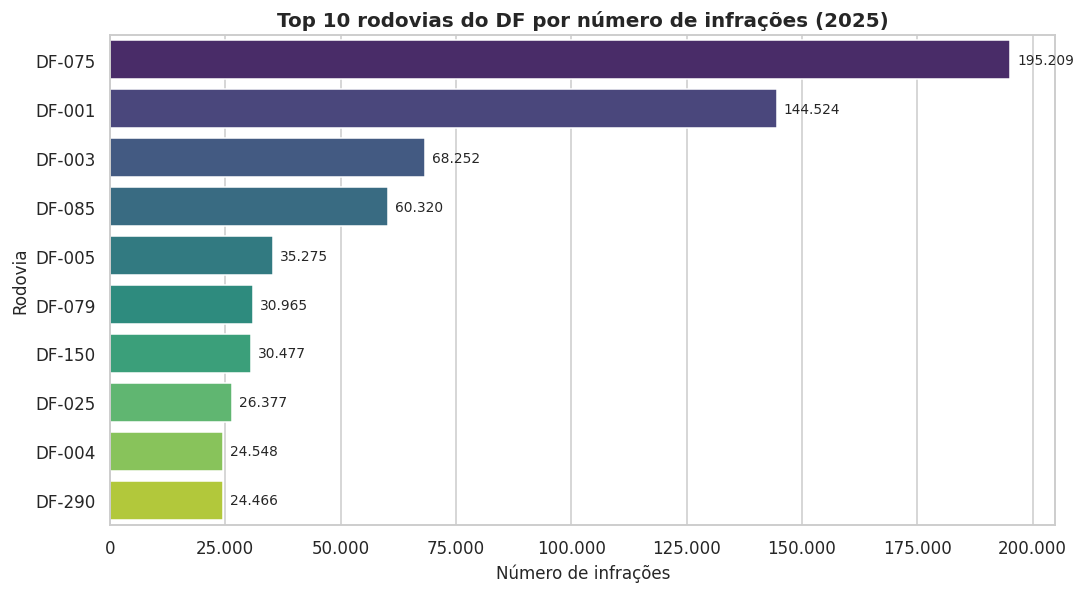

In [11]:
top_rod = (df_limpo[df_limpo["rodovia"] != "outra/nao identificada"]
           ["rodovia"].value_counts().head(10))

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(x=top_rod.values, y=[r.upper() for r in top_rod.index],
            hue=[r.upper() for r in top_rod.index], palette=PALETA, legend=False, ax=ax)
ax.set_title("Top 10 rodovias do DF por número de infrações (2025)")
ax.set_xlabel("Número de infrações")
ax.set_ylabel("Rodovia")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", ".")))
for i, v in enumerate(top_rod.values):
    ax.text(v + 1500, i, f"{v:,}".replace(",", "."), va="center", fontsize=9)
plt.tight_layout()
plt.show()

**Interpretação:** As infrações são **fortemente concentradas em poucas vias**. A **DF-075 (EPNB)** lidera com folga, seguida pela **DF-001 (EPCT, o Anel Viário)** e pela **DF-003 (EPIA)**. Essas três vias sozinhas concentram a maior parte dos registros identificáveis — são corredores de alto fluxo do DF. Isso aponta que a fiscalização (e o risco) está geograficamente concentrada, não espalhada de forma uniforme pelas rodovias.

### Gráfico 2 — QUANDO: volume de infrações por mês

*Pergunta: existe diferença entre os meses do ano no volume de infrações?*

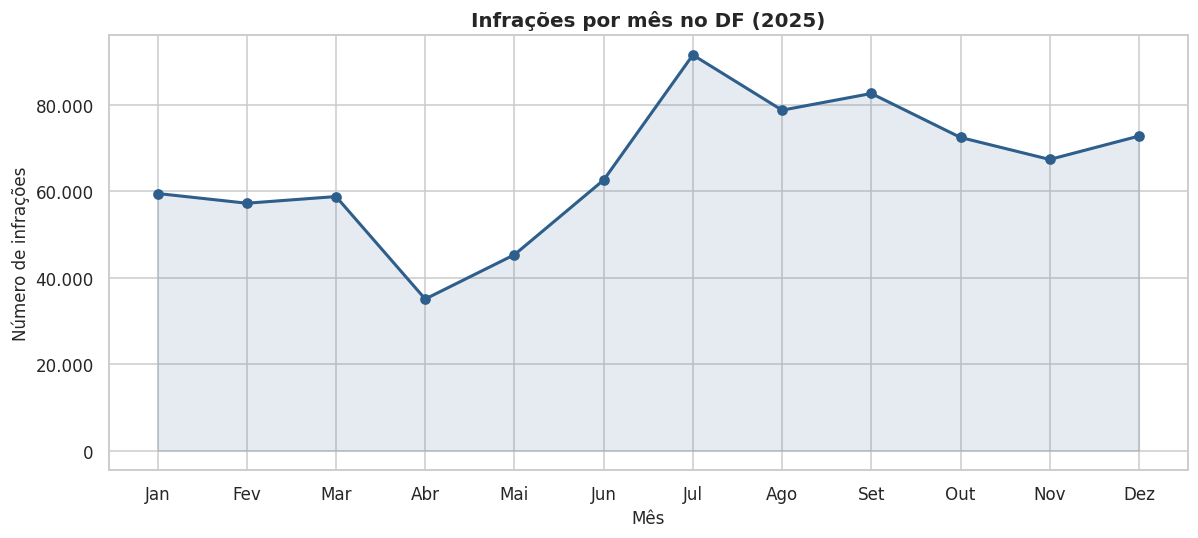

In [12]:
meses_nome = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
              "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
por_mes = df_limpo["mes"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(por_mes.index, por_mes.values, marker="o", color=COR, linewidth=2)
ax.fill_between(por_mes.index, por_mes.values, alpha=0.12, color=COR)
ax.set_title("Infrações por mês no DF (2025)")
ax.set_xlabel("Mês")
ax.set_ylabel("Número de infrações")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses_nome)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{int(y):,}".replace(",", ".")))
plt.tight_layout()
plt.show()

**Interpretação:** O volume de infrações **varia ao longo do ano**, sem uma tendência única de crescimento ou queda — há meses de pico e meses de vale. Essa oscilação provavelmente reflete a intensidade da fiscalização (campanhas, radares ativos) mais do que uma mudança real de comportamento dos motoristas, já que o número de carros nas ruas não muda tanto mês a mês. É um ponto a tratar com honestidade: **o dado mede infrações *registradas*, que dependem de fiscalização**, e não necessariamente todas as infrações que ocorreram.

### Gráfico 3 — QUANDO: infrações por dia da semana

*Pergunta: os dias úteis e os fins de semana se comportam de forma diferente?*

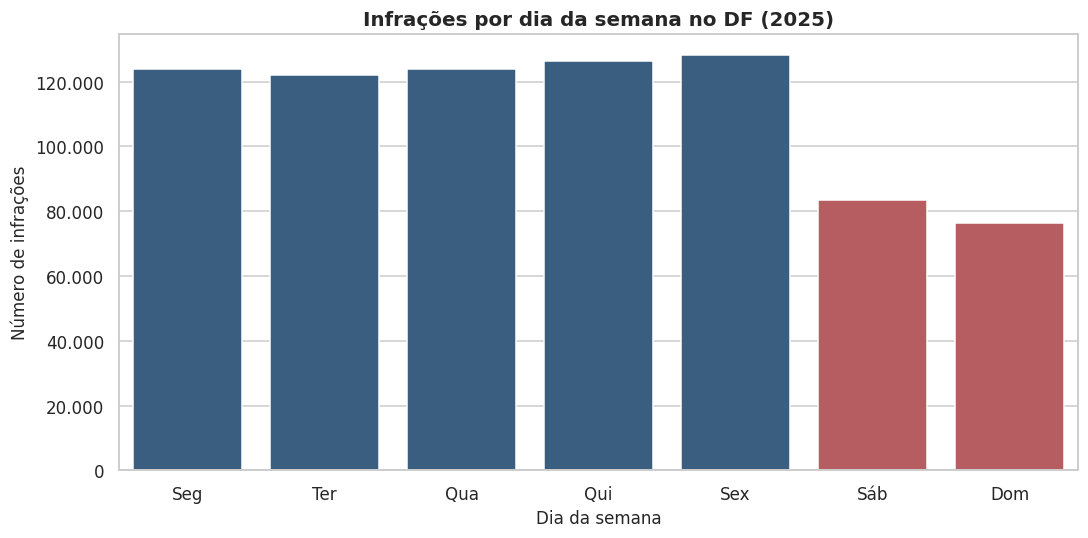

In [13]:
ordem_dias = ["segunda-feira", "terca-feira", "quarta-feira", "quinta-feira",
              "sexta-feira", "sabado", "domingo"]
rotulo_dias = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
por_dia = df_limpo["dia_da_semana"].value_counts().reindex(ordem_dias)

cores = [COR]*5 + ["#C44E52"]*2  # destaca fim de semana
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=rotulo_dias, y=por_dia.values, palette=cores, hue=rotulo_dias, legend=False, ax=ax)
ax.set_title("Infrações por dia da semana no DF (2025)")
ax.set_xlabel("Dia da semana")
ax.set_ylabel("Número de infrações")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{int(y):,}".replace(",", ".")))
plt.tight_layout()
plt.show()

**Interpretação:** Os **dias úteis (azul)** concentram bem mais infrações que o **fim de semana (vermelho)**. Sexta-feira é o pico e o domingo é o menor. Isso é coerente com o volume de tráfego: durante a semana há o deslocamento casa-trabalho, com mais carros, mais radares ativos em horário comercial e, portanto, mais autuações. Reforça a ideia de que o **perfil de risco está ligado ao trânsito de rotina (deslocamento pendular)**, não ao lazer de fim de semana.

### Gráfico 4 — QUANDO: distribuição das infrações por hora do dia

*Pergunta: em quais horários as infrações se concentram?*

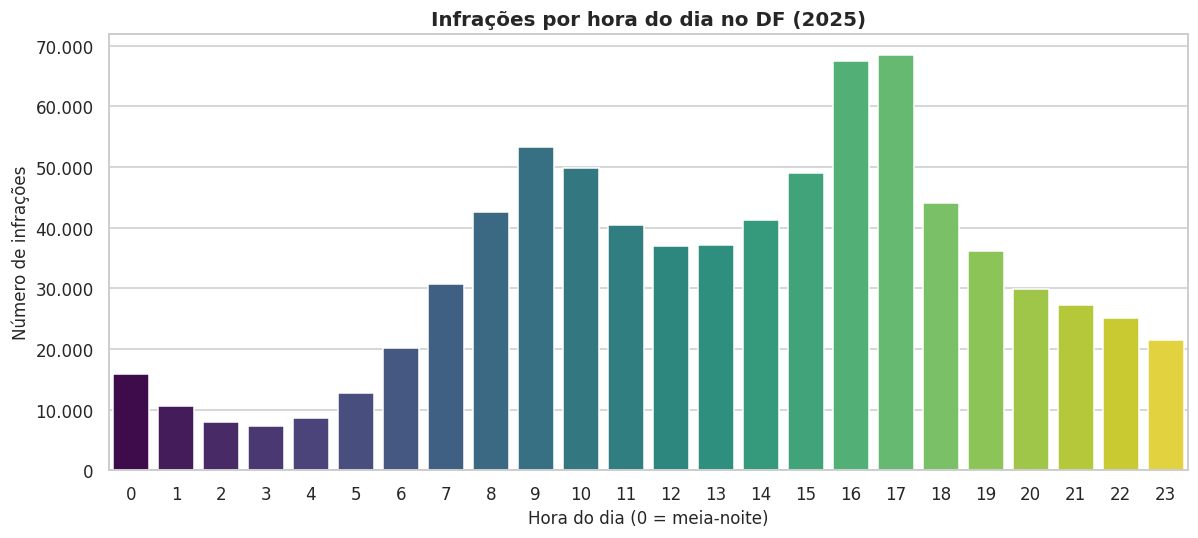

In [14]:
por_hora = df_limpo["hora"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(x=por_hora.index, y=por_hora.values,
            hue=por_hora.index, palette=PALETA, legend=False, ax=ax)
ax.set_title("Infrações por hora do dia no DF (2025)")
ax.set_xlabel("Hora do dia (0 = meia-noite)")
ax.set_ylabel("Número de infrações")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{int(y):,}".replace(",", ".")))
plt.tight_layout()
plt.show()

**Interpretação:** As infrações se concentram nas **horas de pico do dia**, com elevação ao longo da manhã e da tarde e queda forte na madrugada. Os horários de maior movimento (deslocamento para trabalho/escola e o retorno no fim da tarde) são os de maior número de autuações. Confirma o padrão dos gráficos anteriores: **o risco está atrelado ao trânsito intenso do dia a dia**.

### Gráfico 5 — COMO: os tipos de infração mais cometidos

*Pergunta: quais comportamentos infratores são mais frequentes?*

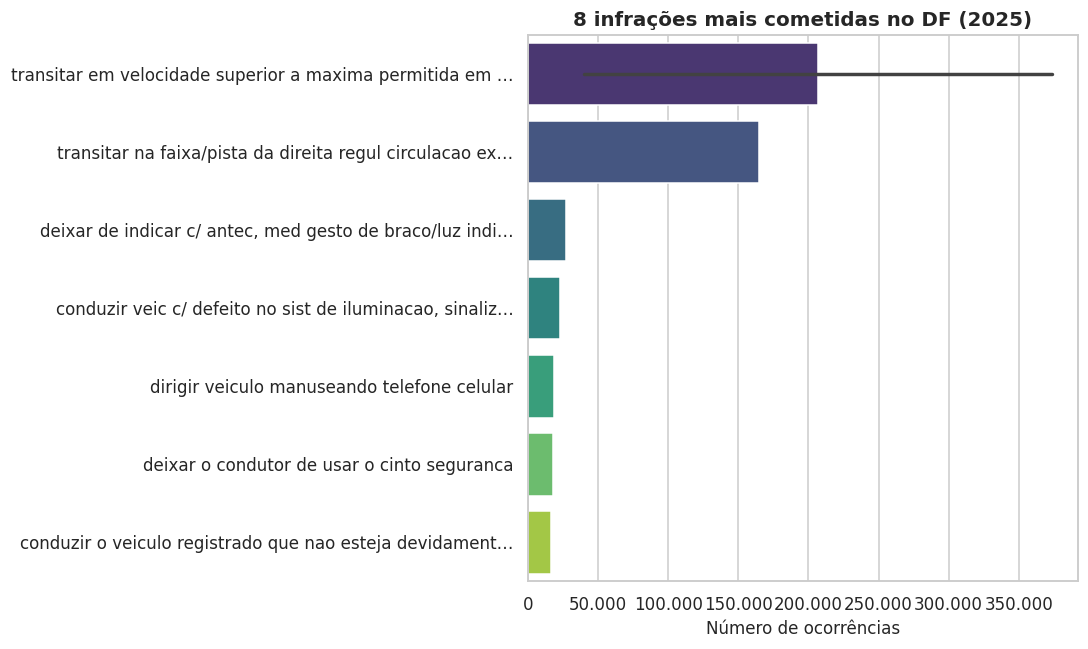

In [15]:
top_inf = df_limpo["descricao"].value_counts().head(8)
# encurtar rótulos longos
rot = [d[:55] + "…" if len(d) > 55 else d for d in top_inf.index]

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_inf.values, y=rot, hue=rot, palette=PALETA, legend=False, ax=ax)
ax.set_title("8 infrações mais cometidas no DF (2025)")
ax.set_xlabel("Número de ocorrências")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", ".")))
plt.tight_layout()
plt.show()

**Interpretação:** O ranking é **dominado pelo excesso de velocidade** — *"transitar em velocidade superior à máxima permitida em até 20%"* é, isolada, a infração mais comum, muito à frente das demais. Em seguida aparece *"transitar na faixa da direita"* e outras condutas. Ou seja, o comportamento infrator nº 1 nas rodovias do DF é **dirigir acima do limite de velocidade**, o fator clássico associado a acidentes mais graves.

### Gráfico 6 — COMO: distribuição das infrações por gravidade

*Pergunta: as infrações são majoritariamente leves ou graves?*

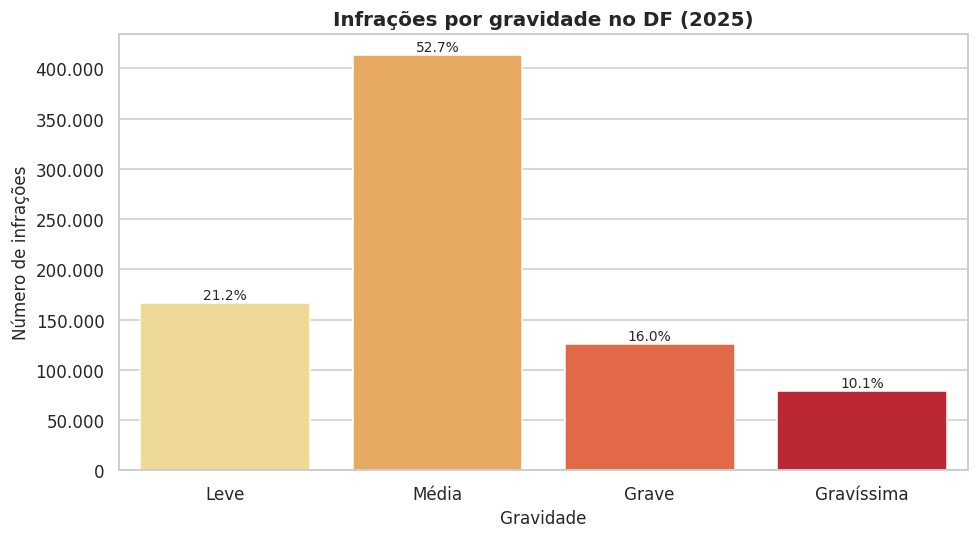

In [16]:
por_grav = df_limpo["grav_tipo"].value_counts().reindex(ordem_grav)
rotulo_grav = ["Leve", "Média", "Grave", "Gravíssima"]

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=rotulo_grav, y=por_grav.values,
            hue=rotulo_grav, palette="YlOrRd", legend=False, ax=ax)
ax.set_title("Infrações por gravidade no DF (2025)")
ax.set_xlabel("Gravidade")
ax.set_ylabel("Número de infrações")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{int(y):,}".replace(",", ".")))
total = por_grav.sum()
for i, v in enumerate(por_grav.values):
    ax.text(i, v + 4000, f"{v/total*100:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

**Interpretação:** A maior parte das infrações é de gravidade **média**, seguida de **leve**. As infrações **graves** e **gravíssimas** somam uma fatia menor, mas longe de desprezível (juntas, cerca de um quarto dos registros). Como a infração mais comum é "velocidade até 20% acima" (classificada como média), faz sentido que essa categoria domine. O fato de existir um volume relevante de gravíssimas é um alerta de segurança.

### Gráfico 7 — QUEM: tipos de veículo mais autuados

*Pergunta: que veículos mais aparecem nos registros?*

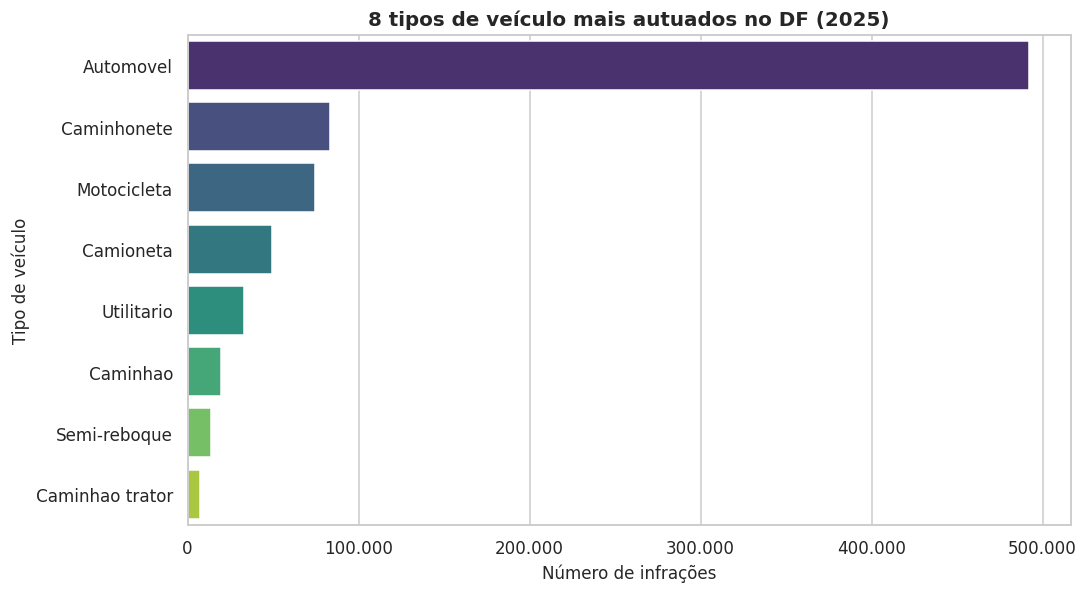

In [17]:
top_veic = df_limpo["tipo_veiculo"].value_counts().head(8)

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(x=top_veic.values, y=[v.capitalize() for v in top_veic.index],
            hue=[v.capitalize() for v in top_veic.index], palette=PALETA, legend=False, ax=ax)
ax.set_title("8 tipos de veículo mais autuados no DF (2025)")
ax.set_xlabel("Número de infrações")
ax.set_ylabel("Tipo de veículo")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", ".")))
plt.tight_layout()
plt.show()

**Interpretação:** O **automóvel** domina amplamente as autuações, o que é esperado por ser o veículo mais comum na frota. Logo depois vêm **caminhonete**, **motocicleta** e **camioneta**. É importante a honestidade aqui: este gráfico mostra **volume absoluto**, não **risco por veículo** — para dizer qual *tipo* é mais infrator proporcionalmente, precisaríamos do tamanho da frota de cada categoria, que **não está nestes dados**. Concluímos apenas que o grosso das infrações vem de automóveis.

### Gráfico 8 — QUANTO: distribuição do valor da multa por gravidade

*Pergunta: o valor da multa acompanha a gravidade da infração?*

/tmp/ipykernel_638/1281335469.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Leve", "Média", "Grave", "Gravíssima"])


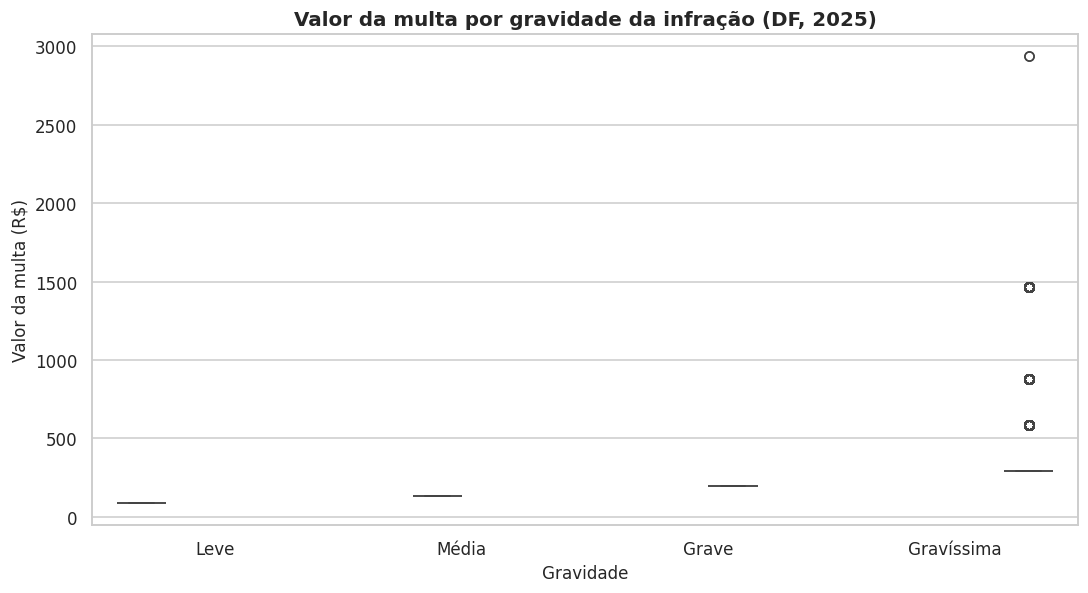

Valor médio e mediano da multa por gravidade:
              mean  median   count
grav_tipo                         
leve         88.38   88.38  166196
media       130.16  130.16  413372
grave       195.23  195.23  125689
gravissima  441.61  293.47   79080


In [18]:
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.boxplot(data=df_limpo, x="grav_tipo", y="valor_multa",
            order=ordem_grav, hue="grav_tipo", palette="YlOrRd", legend=False, ax=ax)
ax.set_title("Valor da multa por gravidade da infração (DF, 2025)")
ax.set_xlabel("Gravidade")
ax.set_ylabel("Valor da multa (R$)")
ax.set_xticklabels(["Leve", "Média", "Grave", "Gravíssima"])
plt.tight_layout()
plt.show()

# tabela de apoio
print("Valor médio e mediano da multa por gravidade:")
print(df_limpo.groupby("grav_tipo", observed=True)["valor_multa"]
      .agg(["mean", "median", "count"]).round(2))

**Interpretação:** O boxplot confirma a relação esperada: **quanto mais grave a infração, maior o valor da multa**. Leves e médias têm valores baixos e concentrados; graves sobem; e as **gravíssimas** têm os maiores valores e a maior dispersão (incluindo multas multiplicadas, que explicam os valores extremos até R\$ 2.934 vistos na estatística inicial). Isso mostra coerência interna do dado: gravidade e penalidade financeira andam juntas.

### Gráfico 9 — QUANTO: histograma do valor das multas

*Pergunta: como se distribui, no geral, o valor pago em multas?*

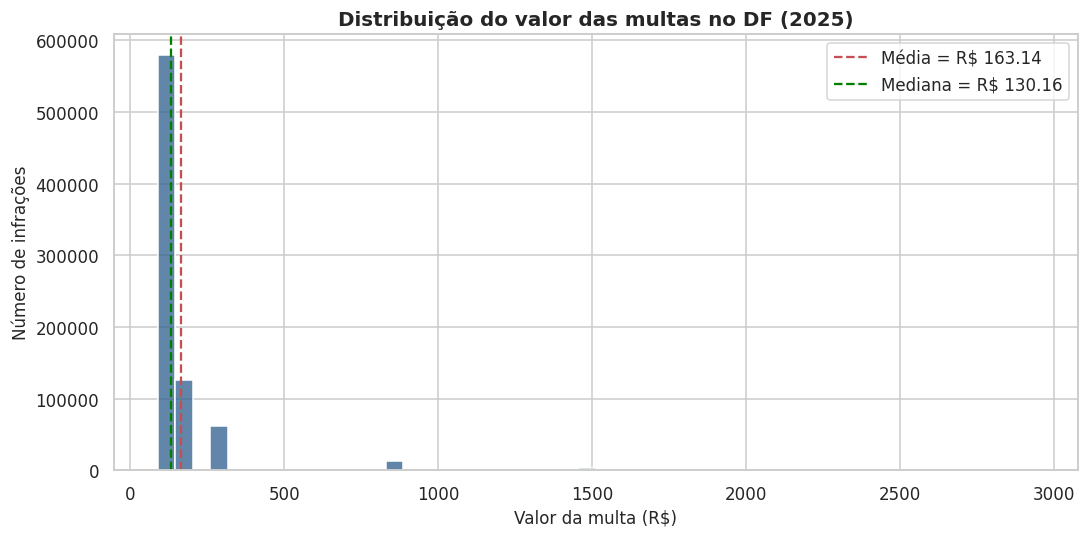

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df_limpo["valor_multa"], bins=50, color=COR, ax=ax)
ax.axvline(df_limpo["valor_multa"].mean(), color="#C44E52", linestyle="--",
           label=f"Média = R$ {df_limpo['valor_multa'].mean():.2f}")
ax.axvline(df_limpo["valor_multa"].median(), color="green", linestyle="--",
           label=f"Mediana = R$ {df_limpo['valor_multa'].median():.2f}")
ax.set_title("Distribuição do valor das multas no DF (2025)")
ax.set_xlabel("Valor da multa (R$)")
ax.set_ylabel("Número de infrações")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretação:** A distribuição é **fortemente assimétrica à direita**: a esmagadora maioria das multas se concentra nos valores mais baixos (em torno de R\$ 130, a moda), com uma cauda longa de multas caras. A linha da média (vermelha) fica à direita da mediana (verde), o que confirma numericamente a assimetria já observada na Seção 1.3. Em termos práticos: a maior parte das autuações é de infração média/leve e barata, mas há um grupo menor de multas pesadas que eleva a média.

## 4. Conclusões

Retomando a pergunta central — *quais são os perfis de risco nas rodovias do DF: onde, quando e como as infrações se concentram?* — chegamos às seguintes conclusões, cada uma sustentada por evidência mostrada acima.

**Conclusão 1 — O risco é geograficamente concentrado (ONDE).**
As infrações não se distribuem de forma uniforme pelo DF: poucas vias respondem pela maior parte dos registros, com destaque para **DF-075 (EPNB), DF-001 (EPCT) e DF-003 (EPIA)** (Gráfico 1). São corredores de alto fluxo. Para reduzir infrações, faz sentido priorizar fiscalização e engenharia de tráfego nessas vias.

**Conclusão 2 — O risco segue o trânsito de rotina (QUANDO).**
As infrações concentram-se em **dias úteis** (pico na sexta, vale no domingo — Gráfico 3) e nas **horas de movimento do dia** (Gráfico 4). O padrão acompanha o deslocamento pendular casa-trabalho, não o lazer de fim de semana. Já a variação **mês a mês** (Gráfico 2) é mais instável e provavelmente reflete a intensidade da fiscalização.

**Conclusão 3 — O comportamento infrator nº 1 é o excesso de velocidade, predominantemente de gravidade média (COMO).**
A infração isolada mais comum é *transitar acima do limite em até 20%* (Gráfico 5), e a gravidade predominante é **média** (Gráfico 6). O valor da multa cresce de forma coerente com a gravidade (Gráfico 8) e o valor típico pago é baixo (~R\$ 130), com uma cauda de multas caras (Gráfico 9). Ou seja: muitas infrações de velocidade "leve", poucas gravíssimas — mas estas últimas, embora minoria, são o ponto de maior preocupação de segurança.

---

### Limitações e honestidade sobre os dados

- **Não medimos risco *por veículo*** (Gráfico 7 mostra volume, não taxa): faltam dados de tamanho da frota para dizer qual *tipo* infringe proporcionalmente mais.
- **Os dados de geolocalização (lat/long) estão corrompidos** e foram descartados; a análise espacial ficou limitada ao código da rodovia.
- **O conjunto registra infrações *fiscalizadas*, não todas as cometidas.** Variações temporais podem refletir radares ativos/campanhas, não apenas o comportamento dos motoristas. Por isso, falamos em "infrações registradas" e evitamos afirmar mudanças de comportamento que o dado não comprova.